In this notebook, we demonstrate a simple modeling approuch using a linear regression on a summary of each timeseries feature

In [2]:
# import packages
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import utils #from utils import *
import more_utils
import importlib
from sklearn.linear_model import LinearRegression as LR
#from matplotlib.colors import ListedColormap, Normalize
#import seaborn as sns
#from statsmodels.tsa.stattools import grangercausalitytests, ccf
#import plotly.express as px
#import geopandas as gpd
#import warnings
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.filterwarnings('ignore', ca"tegory=RuntimeWarning)
#import json
#import pickle
#from pmdarima import auto_arima 
#from sklearn.model_selection import train_test_split
#from scipy import signal
#from statsmodels.tsa.stattools import adfuller
#from statsmodels.tsa.statespace.sarimax import SARIMAX 
#from random import random

First let's read in the aggregated data:

In [ ]:
# read in aggregated data
agg_data = pd.read_parquet('./data/eaglei_noaa_era5_engineered.parquet')

We will build our model at the county level. In our model, we will take each observation to consist of the previous 5 days of weather data, with the target being tomorrow's maximum fraction of people without power. Instead of training on timeseries observations, we summarize each timeseries feature so that the observation consists of a vector of summary features.

Training model for county fips: 29067
   Training RMSE: 38.651595573483604
   Validation RMSE: 309.17070935227684
Training model for county fips: 53033
   Training RMSE: 5158.457703638438
   Validation RMSE: 6769.7225030220125


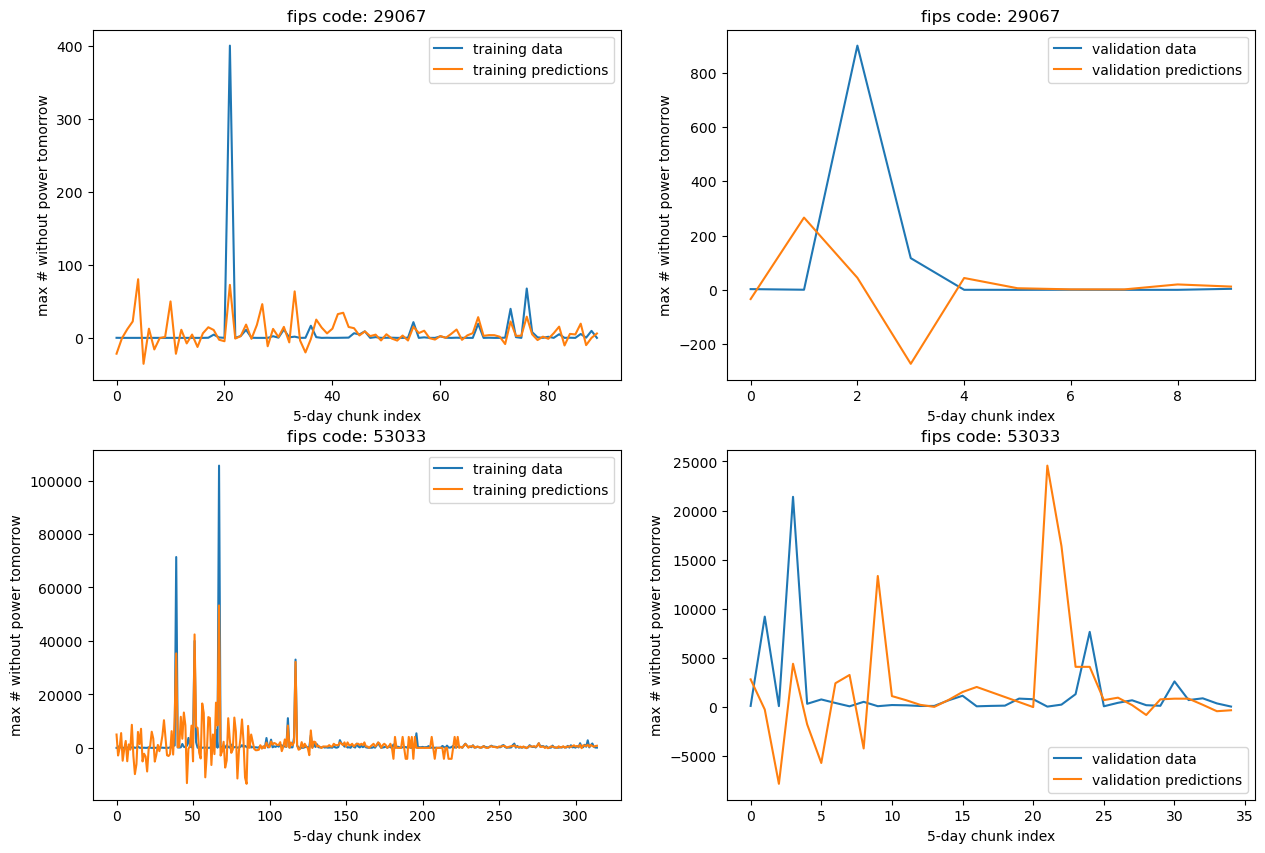

In [35]:
# choose a list of fips (county) codes to build models for. We will build a differnt model for each county.
all_fips = list(set(agg_data['fips_code']))
fips_list = [29067, 53033] # Providence or Boulder, Seattle
#fips_list = np.random.choice(all_fips, 6)
n_counties = len(fips_list)

# choose how long the training interval should be
n_days_X = 5
interval_X = int((24/6)*n_days_X) # 5 previous days, at 6 hr cadence
interval_y = int(24/6*1) # tomorrow

# whether or not to plot the predictions
make_plots = True
if make_plots:
    plt.figure(figsize = [15,5*n_counties])
    k = 1

# loop over and build a model for each county
county_train_RMSEs = []
county_val_RMSEs = []
for j in range(len(fips_list)):
    fips = fips_list[j]
    print('Training model for county fips: ' + str(fips))
    
    # chunk the data into observations 
    #if not os.path.exists('./data/X_chunked_agg_' + str(fips) + '_' + file_prefix + '.pkl'):
    X_chunked, y_chunked, time_pred_start = more_utils.chunk_aggregated_engineered_data(agg_data, fips, './data', '', interval_X, interval_y)
    #else:
    #    X_chunked = pd.read_pickle('./data/X_chunked_agg_' + str(fips) + '_' + file_prefix + '.pkl') # 16 timesteps, 25 predictors, 365 chunks
    #    y_chunked = pd.read_pickle('./data/y_chunked_agg_' + str(fips) + '_' + file_prefix + '.pkl')
    n_chunks = X_chunked.shape[2]
    n_features = X_chunked.shape[1]
    X_simple = np.zeros((n_chunks, 2*n_features + 3))
    y_simple = np.zeros(n_chunks)
    
    # summarize timeseries observations
#     drop_chunk_idxs = []
    for i in range(n_chunks):
#         if np.isnan(X_chunked[:,:,i]).all(): 
#             print('chunk ' + str(i) + ' contains only Nan')
#             #drop_chunk_idxs += [i]
        now_datetime = time_pred_start[i] # time that we are predicting out from for this chunk        
        X_simple[i,:n_features] = np.sum(X_chunked[:,:,i], axis = 0) # total of each event in the last 4 days
        X_simple[i,n_features:] = np.mean(X_chunked[:10,:,i]) - np.mean(X_chunked[-10:,:,i]) # measure of magnitude and sign of trend over the 4 days
        X_simple[i,-3] =  np.max(y_chunked[:,:,i-2]) # how many max people were without power yesterday
        X_simple[i,-2] =  np.max(y_chunked[:,:,i-1]) # how many max people were without power today    
        X_simple[i,-1] =  now_datetime.to_numpy() # we will drop before training, but want to preserve during train-test split   
        y_simple[i] = np.max(y_chunked[:,:,i]) # max number of people w/o power over the next day

    # remove Nan chunks (occasionally data was not recorded for a county over a specific interval)
    #cols = list(df_state_ts_comb_hr.columns)[0:-1] # remove predictor column name, features might be different per state
    X_simple = pd.DataFrame(X_simple)#, columns = cols)#.shape
    not_nan_idxs = np.invert(X_simple.isna().any(axis=1))
    X_simple = X_simple[not_nan_idxs] # remove Nan rows
    y_simple = y_simple[not_nan_idxs] 
    n_chunks_total = len(y_simple)
    
    # split into training-validation and test sets (most recent 10% into test set)
    #X_train_val, X_test, y_train_val, y_test, = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
    #X_train, X_val, y_train, y_val, = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)
    n_chunks_train_val = int(n_chunks_total*0.9)
    X_train_val = X_simple.iloc[0:n_chunks_train_val,:]
    y_train_val = y_simple[0:n_chunks_train_val]
    X_test = X_simple.iloc[n_chunks_train_val:,:]
    y_test = y_simple[n_chunks_train_val:]    
    n_chunks_test = len(y_test)
    
    # collect datetimes and drop from X
    train_val_datetimes = X_train_val.iloc[:,-1]
    test_datetimes = X_test.iloc[:,-1]
    X_train_val = X_train_val.iloc[:,:-1]
    X_test = X_test.iloc[:,:-1]
    # val_datetimes = X_val.iloc[:,-1]
    #  X_val = X_val.iloc[:,:-1]
    
    # Cross validation: train on first N chunks, validate on chunks N:N+5, iterate
    N = 50
    n_val = 5
    val_true = np.array([])
    val_preds = np.array([])
    train_true = np.array([])
    train_preds = np.array([])
    for j in range(int(n_chunks_total/N)-1):
        X_train = X_train_val.iloc[j*N:(j+1)*N - n_val, :] # jth set of chunks, minus validation subset of chunks
        y_train = y_train_val[j*N:(j+1)*N - n_val] # jth set of chunks, minus validation subset of chunks
        X_val = X_train_val.iloc[(j+1)*N - n_val:(j+1)*N, :]
        y_val = y_train_val[(j+1)*N - n_val:(j+1)*N]
        reg = LR().fit(X_train, y_train)
        y_pred_train = reg.predict(X_train)
        y_pred_val = reg.predict(X_val)
        train_true = np.append(train_true, y_train) #+= [y_train]
        train_preds = np.append(train_preds, y_pred_train) #+= [y_pred_train]
        val_true = np.append(val_true, y_val) #+= [y_val]
        val_preds = np.append(val_preds, y_pred_val) #+= [y_pred_val]

    # calculate overall RMSE over training set
    #train_true = np.array(train_true)
    #train_preds = np.array(train_preds)
    RMSE = np.sqrt(np.mean((train_true - train_preds)**2))
    county_train_RMSEs += [RMSE]
    print('   Training RMSE: ' + str(RMSE))
    
    # calculate overall RMSE over validation set
    #val_true = np.array(val_true)
    #val_preds = np.array(val_preds)
    RMSE = np.sqrt(np.mean((val_true - val_preds)**2))
    county_val_RMSEs += [RMSE]
    print('   Validation RMSE: ' + str(RMSE))
    
    
    if make_plots:
        plt.subplot(n_counties, 2, k)
        index = np.linspace(0,len(train_preds) -1,len(train_preds))
        #plt.plot(val_datetimes, y_val, label = 'validation data')
        #plt.plot(val_datetimes, y_pred, label = 'validation predictions')
        plt.plot(index, train_true, label = 'training data')
        plt.plot(index, train_preds, label = 'training predictions')
        plt.xlabel(str(n_days_X)+'-day chunk index')
        plt.ylabel('max # without power tomorrow')
        plt.title('fips code: ' + str(fips))
        plt.legend()
        k+=1
        plt.subplot(n_counties, 2, k)
        index = np.linspace(0,len(val_preds) -1,len(val_preds))
        #plt.plot(val_datetimes, y_val, label = 'validation data')
        #plt.plot(val_datetimes, y_pred, label = 'validation predictions')
        plt.plot(index, val_true, label = 'validation data')
        plt.plot(index, val_preds, label = 'validation predictions')
        plt.xlabel(str(n_days_X)+'-day chunk index')
        plt.ylabel('max # without power tomorrow')
        plt.legend()
        plt.title('fips code: ' + str(fips))
        k+=1
